In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Feature Dataset
df = pd.read_csv('features_dataset.csv')

In [3]:
#Check Dataset
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud
0,244486.46,8946.00,0.00,526950.37,771436.84,1,999.0,0
1,3170.28,58089.00,54918.72,0.00,0.00,1,999.0,0
2,8424.74,783.00,0.00,0.00,0.00,1,999.0,0
3,261877.19,7596.00,269473.19,1126627.70,864750.51,1,999.0,0
4,20528.65,2302074.12,2322602.77,82696.17,62167.52,1,999.0,0


In [4]:
#Check shape:
df.shape

(6362620, 8)

In [5]:
#Check columns
df.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'transaction_frequency', 'velocity', 'isFraud'],
      dtype='object')

In [6]:
#Check Class Distribution
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
#Percentage
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [8]:
#Create Features and Target
X = df.drop('isFraud', axis=1)

In [9]:
#Target:
y = df['isFraud']

In [10]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(5090096, 7)
(1272524, 7)


In [12]:
#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
#Generate Predictions
y_pred = rf.predict(X_test)

In [14]:
#Accuracy
accuracy_score(
    y_test,
    y_pred
)

0.9995850765879465

In [15]:
#Precision
precision_score(
    y_test,
    y_pred
)

0.94351630867144

In [16]:
#Recall
recall_score(
    y_test,
    y_pred
)

0.7218502738892271

In [17]:
#F1 Score
f1_score(
    y_test,
    y_pred
)

0.8179310344827586

In [18]:
#Full Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.94      0.72      0.82      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.86      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



In [19]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1270810,      71],
       [    457,    1186]])

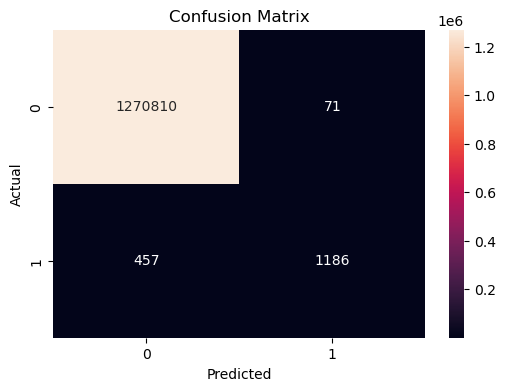

In [21]:
#Visualize
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [22]:
#Calculate False Positive Ratio
tn, fp, fn, tp = cm.ravel()

In [23]:
fpr = fp / (fp + tn)

print(
    "False Positive Ratio:",
    round(fpr,4)
)

False Positive Ratio: 0.0001


In [24]:
#Fraud Capture Rate (FCR)
fcr = tp / (tp + fn)

print(
    "Fraud Capture Rate:",
    round(fcr,4)
)

Fraud Capture Rate: 0.7219


In [25]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [26]:
#Sort:
importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,oldbalanceOrg,0.449094
0,amount,0.235557
4,newbalanceDest,0.179990
2,newbalanceOrig,0.068150
3,oldbalanceDest,0.066639
6,velocity,0.000384
5,transaction_frequency,0.000187


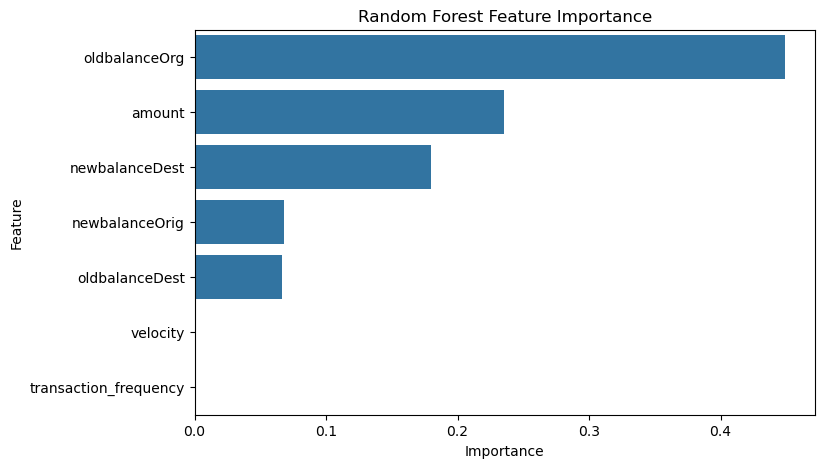

In [27]:
#Plot Feature Importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

In [28]:
#Save Trained Model
import joblib

joblib.dump(
    rf,
    'random_forest_model.pkl'
)

['random_forest_model.pkl']

In [29]:
#Verify:
import os

os.path.exists(
    'random_forest_model.pkl'
)

True